[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/gasquality/gas_blending_quality_optimization.ipynb)

# Natural-gas blending and quality optimization with NeqSim

Gas blending can recover value from a rich stream only when the delivered mixture remains
interchangeable, single phase, and within its commercial specification. This tutorial combines
NeqSim's ISO 6976:2016 calculations with an SRK hydrocarbon-dew-point flash to turn two public,
synthetic gas analyses into a transparent blend decision.

The numerical limits below are illustrative project constraints, not universal sales-gas or
regulatory limits. Always use the contractual standard edition, reference conditions, sampling
basis, uncertainty rules, and limits that apply to the real delivery point.

## Learning objectives

After completing the notebook, you should be able to:

1. construct and normalize two natural-gas analyses;
2. calculate GCV, LCV, Wobbe index, relative density, and reference-state compressibility;
3. calculate hydrocarbon dew point at delivery pressure;
4. screen every molar blend fraction against simultaneous quality constraints;
5. distinguish a nominal maximum-value blend from an uncertainty-aware blend; and
6. validate composition, standard-property identities, trends, and delivered energy.

Compositions are dry mole fractions. Pressure is absolute (`bara`), temperature is °C, and
volumetric energy properties use 15°C combustion and volume reference temperatures.

## 1. Colab-compatible setup

The setup installs the latest public PyPI release only when `neqsim` is absent. A clean Colab
runtime therefore needs no local source checkout, editable installation, private wheel, or
manually supplied JAR.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

In [2]:
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from importlib.metadata import version
from neqsim import jneqsim


java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            version("neqsim"),
            platform.python_version(),
            java_version,
        ],
    }
)
display(runtime_table)

  Runtime                               Version
0  NeqSim                                3.16.0
1  Python                               3.12.13
2    Java  openjdk version "17.0.19" 2026-04-21


## 2. Engineering basis and model choices

Two synthetic dry gases arrive at the same reference state, so a molar blend fraction is also a
convenient standard-volume screening basis. The **lean gas** has more methane, nitrogen, and
CO₂; the **rich gas** has more ethane through hexane. The blend is evaluated at 70 bara for
hydrocarbon dew point.

NeqSim's `Standard_ISO6976_2016` supplies energy and interchangeability properties. The SRK
equation of state with the classic mixing rule supplies the phase-equilibrium model. ISO 6976
uses its own standard-prescribed reference-property calculation; the SRK model does not replace
that standard. Water, H₂S, oxygen, helium, and unknown heavy fractions are outside this example.

In [3]:
LEAN_GAS = {
    "nitrogen": 0.020,
    "CO2": 0.015,
    "methane": 0.926,
    "ethane": 0.025,
    "propane": 0.008,
    "i-butane": 0.002,
    "n-butane": 0.002,
    "n-pentane": 0.001,
    "n-hexane": 0.001,
}

RICH_GAS = {
    "nitrogen": 0.008,
    "CO2": 0.005,
    "methane": 0.820,
    "ethane": 0.080,
    "propane": 0.045,
    "i-butane": 0.015,
    "n-butane": 0.015,
    "i-pentane": 0.004,
    "n-pentane": 0.004,
    "n-hexane": 0.004,
}

DELIVERY_PRESSURE_BARA = 70.0
VOLUME_REFERENCE_TEMPERATURE_C = 15.0
COMBUSTION_REFERENCE_TEMPERATURE_C = 15.0

all_components = sorted(set(LEAN_GAS) | set(RICH_GAS))
composition_table = pd.DataFrame(
    {
        "Component": all_components,
        "Lean gas (mol%)": [100.0 * LEAN_GAS.get(name, 0.0) for name in all_components],
        "Rich gas (mol%)": [100.0 * RICH_GAS.get(name, 0.0) for name in all_components],
    }
)
display(composition_table)
print(f"Lean composition sum: {sum(LEAN_GAS.values()):.12f}")
print(f"Rich composition sum: {sum(RICH_GAS.values()):.12f}")

   Component  Lean gas (mol%)  Rich gas (mol%)
0        CO2              1.5              0.5
1     ethane              2.5              8.0
2   i-butane              0.2              1.5
3  i-pentane              0.0              0.4
4    methane             92.6             82.0
5   n-butane              0.2              1.5
6   n-hexane              0.1              0.4
7  n-pentane              0.1              0.4
8   nitrogen              2.0              0.8
9    propane              0.8              4.5
Lean composition sum: 1.000000000000
Rich composition sum: 1.000000000000


## 3. Blending, energy quality, and dew point

For rich-gas molar fraction $r$, every blend component is obtained from

$$
x_i(r) = (1-r)x_{i,L} + r x_{i,R}
$$

ISO 6976 first combines pure-component ideal molar calorific values:

$$
H_s^{\mathrm{id}} = \sum_i x_i H_{s,i}^{\circ}
$$

It converts the result to a real-gas volumetric GCV at reference pressure $p_0$:

$$
H_s^{\mathrm{vol}} = H_s^{\mathrm{id}}\frac{p_0}{R T_0 Z_0}
$$

The superior Wobbe index is

$$
W_s = \frac{H_s^{\mathrm{vol}}}{\sqrt{d}}
$$

where $d$ is relative density to air. At the hydrocarbon dew point, the first infinitesimal
liquid is in fugacity equilibrium with the gas, so $f_i^g=f_i^l$ for every component $i$.

In [4]:
def blend_compositions(lean_composition, rich_composition, rich_fraction):
    component_names = sorted(set(lean_composition) | set(rich_composition))
    return {
        component: (
            (1.0 - rich_fraction) * lean_composition.get(component, 0.0)
            + rich_fraction * rich_composition.get(component, 0.0)
        )
        for component in component_names
    }


def build_srk_gas(composition, temperature_c, pressure_bara):
    gas = jneqsim.thermo.system.SystemSrkEos(
        temperature_c + 273.15,
        pressure_bara,
    )

    for component, mole_fraction in composition.items():
        gas.addComponent(component, mole_fraction)

    gas.setMixingRule("classic")
    gas.init(0)
    return gas


def calculate_iso6976_quality(composition, edition="2016"):
    gas = build_srk_gas(
        composition,
        VOLUME_REFERENCE_TEMPERATURE_C,
        1.01325,
    )
    if edition == "2016":
        standard_class = jneqsim.standards.gasquality.Standard_ISO6976_2016
    else:
        standard_class = jneqsim.standards.gasquality.Standard_ISO6976

    standard = standard_class(
        gas,
        VOLUME_REFERENCE_TEMPERATURE_C,
        COMBUSTION_REFERENCE_TEMPERATURE_C,
        "volume",
    )
    standard.setReferenceState("real")
    standard.calculate()
    undefined_components = [
        str(component)
        for component in standard.getComponentsNotDefinedByStandard()
    ]
    return {
        "GCV (MJ/m3)": float(standard.getValue("GCV")) / 1000.0,
        "LCV (MJ/m3)": float(standard.getValue("LCV")) / 1000.0,
        "Wobbe (MJ/m3)": (
            float(standard.getValue("SuperiorWobbeIndex")) / 1000.0
        ),
        "Relative density (-)": float(standard.getValue("RelativeDensity")),
        "Reference Z (-)": float(standard.getValue("CompressionFactor")),
        "Molar mass (g/mol)": float(standard.getValue("MolarMass")),
        "Undefined components": undefined_components,
    }


def calculate_hydrocarbon_dew_point(composition, pressure_bara):
    gas = build_srk_gas(composition, 0.0, pressure_bara)
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(gas)
    operations.dewPointTemperatureFlash()
    return float(gas.getTemperature("C"))


def evaluate_blend(rich_fraction, rich_composition=RICH_GAS):
    composition = blend_compositions(LEAN_GAS, rich_composition, rich_fraction)
    quality = calculate_iso6976_quality(composition)
    quality["Rich gas fraction (-)"] = rich_fraction
    quality["CO2 (mol%)"] = 100.0 * composition.get("CO2", 0.0)
    quality["HC dew point at 70 bara (°C)"] = calculate_hydrocarbon_dew_point(
        composition,
        DELIVERY_PRESSURE_BARA,
    )
    return composition, quality

## 4. Feed and base-blend diagnostics

The 30 mol% rich-gas case is a reproducible base blend. The table reports standard properties
and the phase-equilibrium constraint together. GCV measures energy per reference volume; Wobbe
index screens burner interchangeability; hydrocarbon dew point screens liquid-dropout risk.

In [5]:
diagnostic_cases = {
    "Lean gas": 0.00,
    "Base blend": 0.30,
    "Rich gas": 1.00,
}
diagnostic_rows = []
diagnostic_compositions = {}

for case_name, rich_fraction in diagnostic_cases.items():
    composition, results = evaluate_blend(rich_fraction)
    diagnostic_compositions[case_name] = composition
    diagnostic_rows.append(
        {
            "Case": case_name,
            **{
                key: value
                for key, value in results.items()
                if key != "Undefined components"
            },
        }
    )

diagnostic_table = pd.DataFrame(diagnostic_rows)
display(diagnostic_table.round(6))

undefined_component_lists = [
    calculate_iso6976_quality(composition)["Undefined components"]
    for composition in diagnostic_compositions.values()
]
print(f"Undefined ISO 6976 components: {undefined_component_lists}")

         Case  GCV (MJ/m3)  ...  CO2 (mol%)  HC dew point at 70 bara (°C)
0    Lean gas    38.216433  ...         1.5                    -31.231727
1  Base blend    40.591466  ...         1.2                     -4.381410
2    Rich gas    46.143756  ...         0.5                     25.018949

[3 rows x 10 columns]
Undefined ISO 6976 components: [[], [], []]


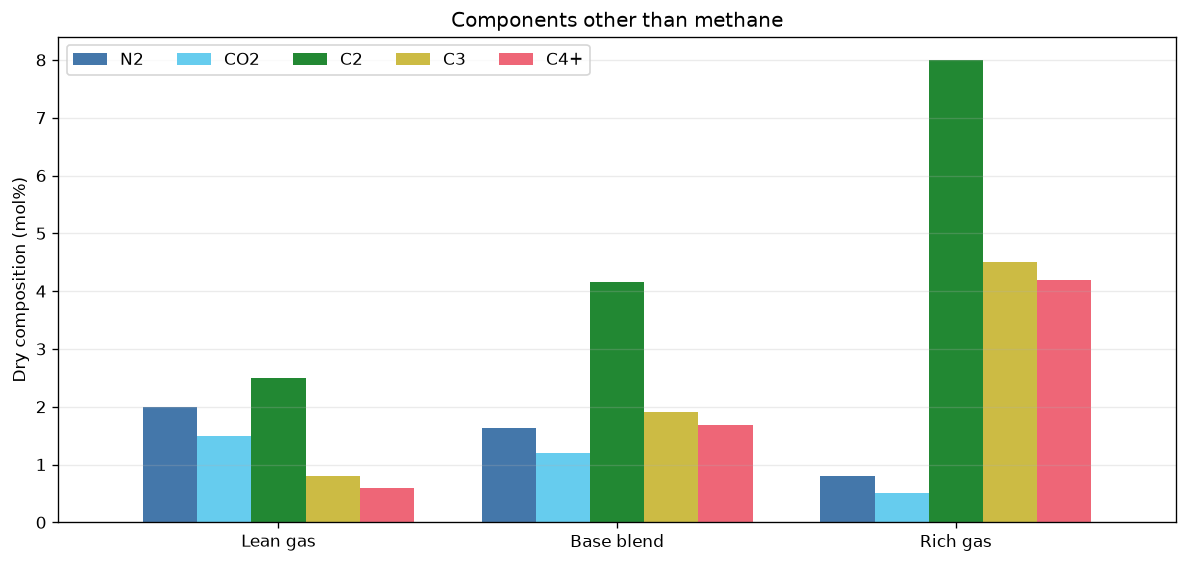

In [6]:
def aggregate_minor_components(composition):
    return {
        "N2": 100.0 * composition.get("nitrogen", 0.0),
        "CO2": 100.0 * composition.get("CO2", 0.0),
        "C2": 100.0 * composition.get("ethane", 0.0),
        "C3": 100.0 * composition.get("propane", 0.0),
        "C4+": 100.0
        * sum(
            fraction
            for component, fraction in composition.items()
            if component
            in {
                "i-butane",
                "n-butane",
                "i-pentane",
                "n-pentane",
                "n-hexane",
            }
        ),
    }


minor_component_table = pd.DataFrame(
    {
        case_name: aggregate_minor_components(composition)
        for case_name, composition in diagnostic_compositions.items()
    }
).T

minor_component_table.plot(
    kind="bar",
    figsize=(10, 4.8),
    width=0.8,
    color=["#4477AA", "#66CCEE", "#228833", "#CCBB44", "#EE6677"],
)
plt.ylabel("Dry composition (mol%)")
plt.title("Components other than methane")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.legend(ncol=5)
plt.tight_layout()
plt.show()

The rich stream increases ethane and heavier hydrocarbons, raising both energy density and
dew point. Wobbe index rises less rapidly than GCV because the blend also becomes denser.
Neither GCV nor Wobbe alone protects against hydrocarbon condensation.

## 5. Illustrative simultaneous specification window

The screening problem maximizes rich-gas use subject to:

| Quantity | Illustrative constraint |
|---|---:|
| GCV at 15/15°C | 39.5 to 42.5 MJ/m³ |
| Superior Wobbe index at 15/15°C | 50.0 to 52.0 MJ/m³ |
| Hydrocarbon dew point at 70 bara | at most 5.0°C |
| CO₂ | at most 1.5 mol% |

These bounds are deliberately labelled illustrative. A real optimization must reproduce the
contract's reference state, standard edition, rounding, uncertainty, and off-spec disposition.

In [7]:
SPECIFICATION = {
    "minimum_gcv_mj_per_m3": 39.5,
    "maximum_gcv_mj_per_m3": 42.5,
    "minimum_wobbe_mj_per_m3": 50.0,
    "maximum_wobbe_mj_per_m3": 52.0,
    "maximum_dew_point_c": 5.0,
    "maximum_co2_mol_percent": 1.5,
}


def is_feasible(results):
    return (
        SPECIFICATION["minimum_gcv_mj_per_m3"]
        <= results["GCV (MJ/m3)"]
        <= SPECIFICATION["maximum_gcv_mj_per_m3"]
        and SPECIFICATION["minimum_wobbe_mj_per_m3"]
        <= results["Wobbe (MJ/m3)"]
        <= SPECIFICATION["maximum_wobbe_mj_per_m3"]
        and results["HC dew point at 70 bara (°C)"]
        <= SPECIFICATION["maximum_dew_point_c"]
        and results["CO2 (mol%)"]
        <= SPECIFICATION["maximum_co2_mol_percent"]
    )


rich_fraction_grid = np.linspace(0.0, 1.0, 101)
grid_rows = []

for rich_fraction in rich_fraction_grid:
    _, results = evaluate_blend(rich_fraction)
    grid_rows.append(
        {
            key: value
            for key, value in results.items()
            if key != "Undefined components"
        }
    )

blend_grid_table = pd.DataFrame(grid_rows)
blend_grid_table["Feasible"] = blend_grid_table.apply(
    lambda row: is_feasible(row),
    axis=1,
)

feasible_grid = blend_grid_table[blend_grid_table["Feasible"]]
print(
    "Nominal feasible rich-gas range: "
    f"{feasible_grid['Rich gas fraction (-)'].min():.2f} to "
    f"{feasible_grid['Rich gas fraction (-)'].max():.2f}"
)

Nominal feasible rich-gas range: 0.17 to 0.47


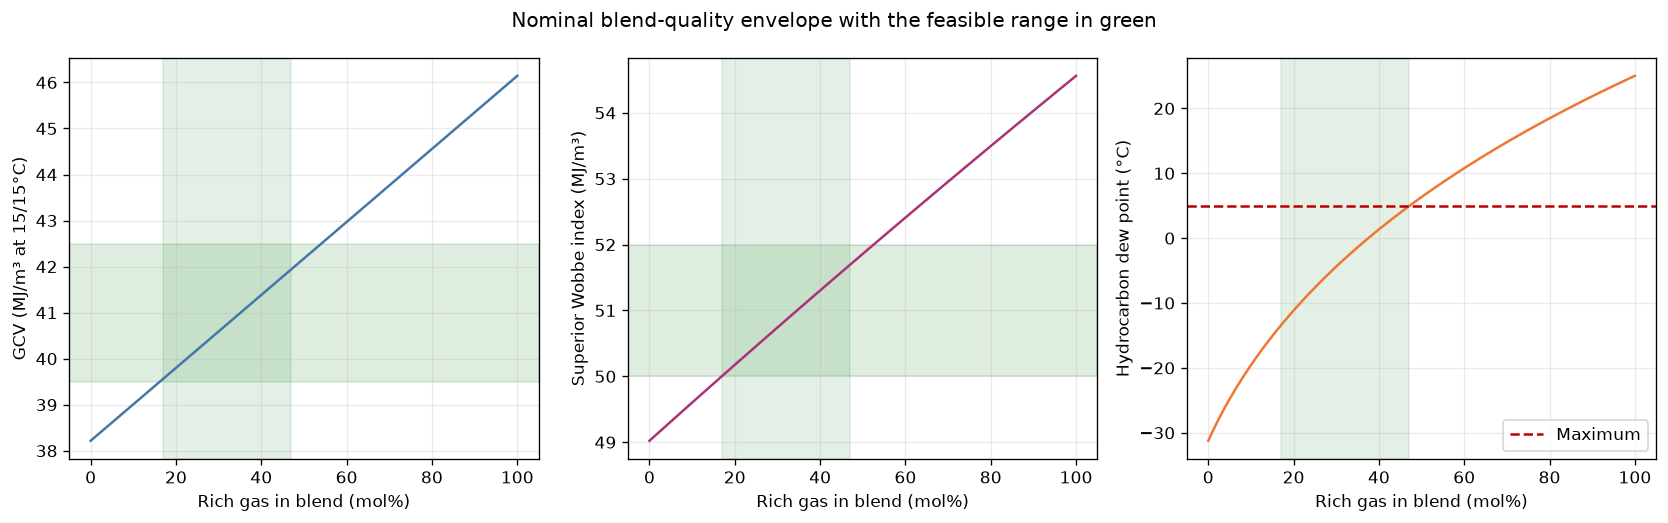

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
rich_percent = 100.0 * blend_grid_table["Rich gas fraction (-)"]
feasible_min_percent = 100.0 * feasible_grid["Rich gas fraction (-)"].min()
feasible_max_percent = 100.0 * feasible_grid["Rich gas fraction (-)"].max()

axes[0].plot(rich_percent, blend_grid_table["GCV (MJ/m3)"], color="#4477AA")
axes[0].axhspan(39.5, 42.5, color="#228833", alpha=0.15)
axes[0].set_ylabel("GCV (MJ/m³ at 15/15°C)")

axes[1].plot(rich_percent, blend_grid_table["Wobbe (MJ/m3)"], color="#AA3377")
axes[1].axhspan(50.0, 52.0, color="#228833", alpha=0.15)
axes[1].set_ylabel("Superior Wobbe index (MJ/m³)")

axes[2].plot(
    rich_percent,
    blend_grid_table["HC dew point at 70 bara (°C)"],
    color="#EE7733",
)
axes[2].axhline(5.0, color="#BB0000", linestyle="--", label="Maximum")
axes[2].set_ylabel("Hydrocarbon dew point (°C)")
axes[2].legend()

for axis in axes:
    axis.axvspan(
        feasible_min_percent,
        feasible_max_percent,
        color="#228833",
        alpha=0.12,
    )
    axis.set_xlabel("Rich gas in blend (mol%)")
    axis.grid(alpha=0.25)

fig.suptitle("Nominal blend-quality envelope with the feasible range in green")
fig.tight_layout()
plt.show()

## 6. Nominal maximum-rich blend

The grid objective is simple: select the largest feasible rich-gas fraction. A 1 percentage-point
grid is appropriate for teaching and makes discretization visible. Production optimization
would normally use a continuous solver plus an operating margin and online composition data.

In [9]:
nominal_selected_row = feasible_grid.iloc[-1]
nominal_rich_fraction = float(nominal_selected_row["Rich gas fraction (-)"])
nominal_composition, nominal_results = evaluate_blend(nominal_rich_fraction)

nominal_selection_table = pd.DataFrame(
    {
        "Quantity": [
            "Rich gas in blend",
            "GCV",
            "Superior Wobbe index",
            "HC dew point at 70 bara",
            "CO2",
        ],
        "Selected value": [
            100.0 * nominal_rich_fraction,
            nominal_results["GCV (MJ/m3)"],
            nominal_results["Wobbe (MJ/m3)"],
            nominal_results["HC dew point at 70 bara (°C)"],
            nominal_results["CO2 (mol%)"],
        ],
        "Unit": ["mol%", "MJ/m3", "MJ/m3", "°C", "mol%"],
    }
)
display(nominal_selection_table.round(6))

                  Quantity  Selected value   Unit
0        Rich gas in blend       47.000000   mol%
1                      GCV       41.938476  MJ/m3
2     Superior Wobbe index       51.692682  MJ/m3
3  HC dew point at 70 bara        4.904206     °C
4                      CO2        1.030000   mol%


The nominal optimum is controlled by hydrocarbon dew point, not by GCV, Wobbe, or CO₂. It sits
close to the 5°C limit and therefore has little tolerance for heavy-end measurement error or
normal operating variability. Reporting only the nominal optimum would hide that engineering
risk.

## 7. Heavy-end uncertainty

Gas chromatography and sampling can under-represent heavy components. We vary n-hexane in the
rich feed from 50% to 150% of its nominal value and offset the change with methane so that every
analysis still sums to one. This is a sensitivity scenario, not a statistical confidence model.

In [10]:
def change_rich_heavy_end(hexane_factor):
    changed_rich_gas = dict(RICH_GAS)
    nominal_hexane = changed_rich_gas["n-hexane"]
    hexane_change = nominal_hexane * (hexane_factor - 1.0)
    changed_rich_gas["n-hexane"] += hexane_change
    changed_rich_gas["methane"] -= hexane_change
    return changed_rich_gas


hexane_factors = np.array([0.50, 0.75, 1.00, 1.25, 1.50])
uncertainty_rows = []

for hexane_factor in hexane_factors:
    changed_rich_gas = change_rich_heavy_end(hexane_factor)
    _, results = evaluate_blend(nominal_rich_fraction, changed_rich_gas)
    uncertainty_rows.append(
        {
            "Rich-feed n-hexane factor (-)": hexane_factor,
            "HC dew point at 70 bara (°C)": results[
                "HC dew point at 70 bara (°C)"
            ],
            "Wobbe (MJ/m3)": results["Wobbe (MJ/m3)"],
        }
    )

uncertainty_table = pd.DataFrame(uncertainty_rows)
display(uncertainty_table.round(6))

   Rich-feed n-hexane factor (-)  HC dew point at 70 bara (°C)  Wobbe (MJ/m3)
0                           0.50                     -0.438664      51.619078
1                           0.75                      2.340529      51.655892
2                           1.00                      4.904206      51.692682
3                           1.25                      7.283933      51.729449
4                           1.50                      9.505342      51.766193


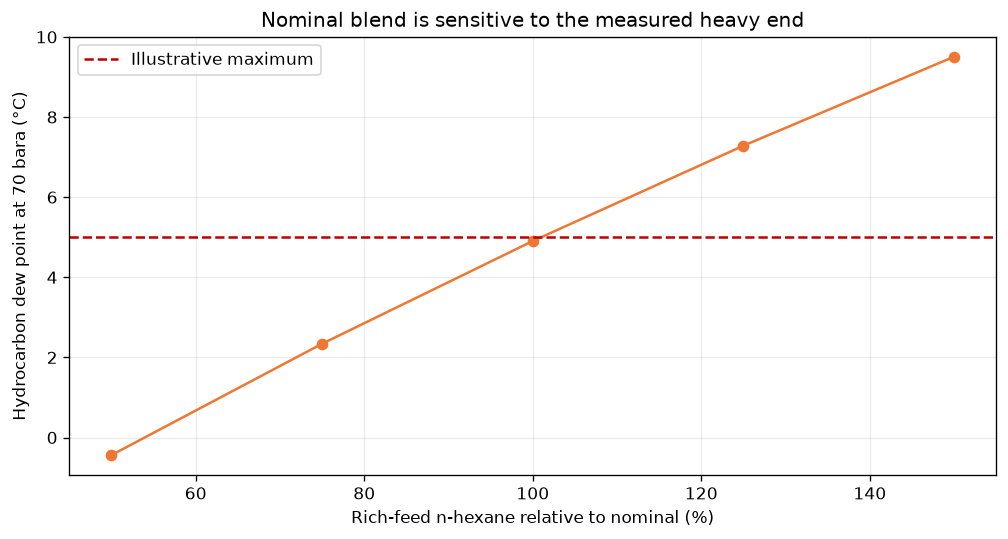

In [11]:
fig, axis = plt.subplots(figsize=(8.5, 4.6))

axis.plot(
    100.0 * uncertainty_table["Rich-feed n-hexane factor (-)"],
    uncertainty_table["HC dew point at 70 bara (°C)"],
    marker="o",
    color="#EE7733",
)
axis.axhline(5.0, color="#BB0000", linestyle="--", label="Illustrative maximum")
axis.set_xlabel("Rich-feed n-hexane relative to nominal (%)")
axis.set_ylabel("Hydrocarbon dew point at 70 bara (°C)")
axis.set_title("Nominal blend is sensitive to the measured heavy end")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
plt.show()

## 8. Uncertainty-aware blend selection

For a simple robust screen, the rich-feed n-hexane is set 25% above nominal and the maximum-rich
search is repeated. The resulting operating point sacrifices some rich-gas capacity to retain
the 5°C dew-point limit in that specified scenario. It is not a substitute for a full uncertainty
distribution, analyzer validation, or an agreed contractual margin.

In [12]:
conservative_rich_gas = change_rich_heavy_end(1.25)
robust_rows = []

for rich_fraction in rich_fraction_grid:
    _, results = evaluate_blend(rich_fraction, conservative_rich_gas)
    robust_rows.append(
        {
            key: value
            for key, value in results.items()
            if key != "Undefined components"
        }
    )

robust_grid_table = pd.DataFrame(robust_rows)
robust_grid_table["Feasible"] = robust_grid_table.apply(
    lambda row: is_feasible(row),
    axis=1,
)
robust_feasible_grid = robust_grid_table[robust_grid_table["Feasible"]]
robust_selected_row = robust_feasible_grid.iloc[-1]
robust_rich_fraction = float(robust_selected_row["Rich gas fraction (-)"])
robust_composition, robust_results = evaluate_blend(
    robust_rich_fraction,
    conservative_rich_gas,
)

selection_comparison = pd.DataFrame(
    {
        "Design": ["Nominal maximum", "Uncertainty-aware"],
        "Rich gas (mol%)": [
            100.0 * nominal_rich_fraction,
            100.0 * robust_rich_fraction,
        ],
        "GCV (MJ/m3)": [
            nominal_results["GCV (MJ/m3)"],
            robust_results["GCV (MJ/m3)"],
        ],
        "Wobbe (MJ/m3)": [
            nominal_results["Wobbe (MJ/m3)"],
            robust_results["Wobbe (MJ/m3)"],
        ],
        "HC dew point (°C)": [
            nominal_results["HC dew point at 70 bara (°C)"],
            robust_results["HC dew point at 70 bara (°C)"],
        ],
    }
)
display(selection_comparison.round(6))

              Design  Rich gas (mol%)  ...  Wobbe (MJ/m3)  HC dew point (°C)
0    Nominal maximum             47.0  ...      51.692682           4.904206
1  Uncertainty-aware             42.0  ...      51.447621           4.693335

[2 rows x 5 columns]


## 9. Pressure path and standard-edition sensitivity

Hydrocarbon dew point can be non-monotonic with pressure for a retrograde gas, so one delivery
pressure does not define the entire operating envelope. We also compare ISO 6976:1995 and 2016
at the uncertainty-aware composition. The editions are close here, but the contract—not
numerical convenience—determines which edition applies.

In [13]:
pressure_values_bara = np.array([35.0, 45.0, 55.0, 65.0, 70.0, 75.0, 85.0])
pressure_rows = []

for pressure_bara in pressure_values_bara:
    dew_point_c = calculate_hydrocarbon_dew_point(
        robust_composition,
        pressure_bara,
    )
    pressure_rows.append(
        {
            "Pressure (bara)": pressure_bara,
            "HC dew point (°C)": dew_point_c,
        }
    )

pressure_table = pd.DataFrame(pressure_rows)
display(pressure_table.round(6))

edition_rows = []
for edition in ["1995", "2016"]:
    edition_quality = calculate_iso6976_quality(robust_composition, edition)
    edition_rows.append(
        {
            "ISO 6976 edition": edition,
            "GCV (MJ/m3)": edition_quality["GCV (MJ/m3)"],
            "Wobbe (MJ/m3)": edition_quality["Wobbe (MJ/m3)"],
            "Relative density (-)": edition_quality["Relative density (-)"],
        }
    )

edition_table = pd.DataFrame(edition_rows)
display(edition_table.round(6))

   Pressure (bara)  HC dew point (°C)
0             35.0           6.533333
1             45.0           7.802984
2             55.0           7.569972
3             65.0           5.999230
4             70.0           4.693335
5             75.0           2.991171
6             85.0          -1.991517
  ISO 6976 edition  GCV (MJ/m3)  Wobbe (MJ/m3)  Relative density (-)
0             1995    41.604324      51.449923              0.653894
1             2016    41.601572      51.447621              0.653866


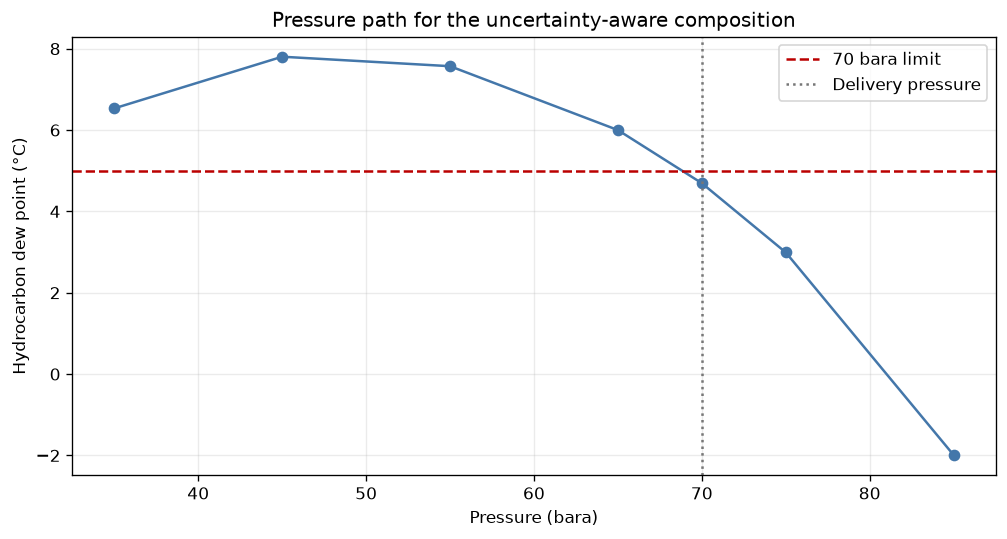

In [14]:
fig, axis = plt.subplots(figsize=(8.5, 4.6))

axis.plot(
    pressure_table["Pressure (bara)"],
    pressure_table["HC dew point (°C)"],
    marker="o",
    color="#4477AA",
)
axis.axhline(5.0, color="#BB0000", linestyle="--", label="70 bara limit")
axis.axvline(70.0, color="#777777", linestyle=":", label="Delivery pressure")
axis.set_xlabel("Pressure (bara)")
axis.set_ylabel("Hydrocarbon dew point (°C)")
axis.set_title("Pressure path for the uncertainty-aware composition")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
plt.show()

## 10. Delivered-energy interpretation

A fixed reference volume does not carry fixed energy when composition changes. The next table
uses 10 million m³/day at 15°C and 1.01325 bara solely as a reporting basis. Daily energy is
GCV times reference volume; conversion uses 3.6 PJ per GWh.

In [15]:
DELIVERY_VOLUME_M3_PER_DAY = 10_000_000.0
energy_cases = {
    "Lean gas": evaluate_blend(0.0)[1],
    "Nominal maximum": nominal_results,
    "Uncertainty-aware": robust_results,
    "Rich gas": evaluate_blend(1.0)[1],
}
energy_rows = []

for case_name, results in energy_cases.items():
    daily_energy_gwh = (
        results["GCV (MJ/m3)"]
        * DELIVERY_VOLUME_M3_PER_DAY
        / 3.6e6
    )
    energy_rows.append(
        {
            "Case": case_name,
            "GCV (MJ/m3)": results["GCV (MJ/m3)"],
            "Reference volume (million m3/day)": (
                DELIVERY_VOLUME_M3_PER_DAY / 1.0e6
            ),
            "Gross energy (GWh/day)": daily_energy_gwh,
        }
    )

energy_table = pd.DataFrame(energy_rows)
display(energy_table.round(6))

                Case  ...  Gross energy (GWh/day)
0           Lean gas  ...              106.156759
1    Nominal maximum  ...              116.495768
2  Uncertainty-aware  ...              115.559922
3           Rich gas  ...              128.177101

[4 rows x 4 columns]


## 11. Automated engineering validation

The final calculation cell verifies identities and decisions independently of rounded display
tables. Failed checks should trigger investigation of composition, API usage, model scope, or
specification logic—not silent tolerance changes.

In [16]:
selected_wobbe_identity = (
    nominal_results["GCV (MJ/m3)"]
    / np.sqrt(nominal_results["Relative density (-)"])
)
selected_wobbe_relative_residual = (
    selected_wobbe_identity - nominal_results["Wobbe (MJ/m3)"]
) / nominal_results["Wobbe (MJ/m3)"]

expected_nominal_composition = {
    component: (
        (1.0 - nominal_rich_fraction) * LEAN_GAS.get(component, 0.0)
        + nominal_rich_fraction * RICH_GAS.get(component, 0.0)
    )
    for component in all_components
}
maximum_blend_residual = max(
    abs(nominal_composition[component] - expected_nominal_composition[component])
    for component in all_components
)

edition_gcv_relative_difference = abs(
    edition_table.loc[0, "GCV (MJ/m3)"]
    - edition_table.loc[1, "GCV (MJ/m3)"]
) / edition_table.loc[1, "GCV (MJ/m3)"]

validation_checks = {
    "lean composition closes": abs(sum(LEAN_GAS.values()) - 1.0) < 1.0e-12,
    "rich composition closes": abs(sum(RICH_GAS.values()) - 1.0) < 1.0e-12,
    "all feed fractions are nonnegative": min(
        list(LEAN_GAS.values()) + list(RICH_GAS.values())
    )
    >= 0.0,
    "ISO components are defined": all(
        len(undefined_components) == 0
        for undefined_components in undefined_component_lists
    ),
    "diagnostic results are finite": bool(
        np.isfinite(
            diagnostic_table.select_dtypes(include=["number"])
        ).all().all()
    ),
    "rich gas GCV exceeds lean gas GCV": (
        diagnostic_table.iloc[-1]["GCV (MJ/m3)"]
        > diagnostic_table.iloc[0]["GCV (MJ/m3)"]
    ),
    "rich gas Wobbe exceeds lean gas Wobbe": (
        diagnostic_table.iloc[-1]["Wobbe (MJ/m3)"]
        > diagnostic_table.iloc[0]["Wobbe (MJ/m3)"]
    ),
    "rich gas dew point exceeds lean gas dew point": (
        diagnostic_table.iloc[-1]["HC dew point at 70 bara (°C)"]
        > diagnostic_table.iloc[0]["HC dew point at 70 bara (°C)"]
    ),
    "blend grid is finite": bool(
        np.isfinite(
            blend_grid_table.select_dtypes(include=["number"])
        ).all().all()
    ),
    "nominal feasible set is nonempty": not feasible_grid.empty,
    "nominal lower boundary is 17 mol%": abs(
        feasible_grid["Rich gas fraction (-)"].min() - 0.17
    )
    < 1.0e-12,
    "nominal maximum is 47 mol%": abs(nominal_rich_fraction - 0.47) < 1.0e-12,
    "nominal selection satisfies every constraint": is_feasible(nominal_results),
    "next nominal grid point is infeasible": not is_feasible(
        evaluate_blend(nominal_rich_fraction + 0.01)[1]
    ),
    "nominal composition closes": abs(sum(nominal_composition.values()) - 1.0)
    < 1.0e-12,
    "linear blend reconstruction closes": maximum_blend_residual < 1.0e-14,
    "Wobbe identity closes": abs(selected_wobbe_relative_residual) < 1.0e-12,
    "heavy-end dew point trend is monotonic": bool(
        np.all(np.diff(uncertainty_table["HC dew point at 70 bara (°C)"]) > 0.0)
    ),
    "nominal design fails high-C6 scenario": (
        uncertainty_table.iloc[3]["HC dew point at 70 bara (°C)"] > 5.0
    ),
    "robust feasible set is nonempty": not robust_feasible_grid.empty,
    "uncertainty-aware maximum is 42 mol%": abs(robust_rich_fraction - 0.42)
    < 1.0e-12,
    "uncertainty-aware selection satisfies constraints": is_feasible(robust_results),
    "uncertainty-aware fraction is below nominal": (
        robust_rich_fraction < nominal_rich_fraction
    ),
    "pressure-path dew points are finite": bool(
        np.isfinite(pressure_table["HC dew point (°C)"]).all()
    ),
    "ISO edition GCV difference is small": edition_gcv_relative_difference < 2.0e-4,
    "reference compressibility is physical": 0.95
    < nominal_results["Reference Z (-)"]
    < 1.05,
    "relative density is physical": 0.5
    < nominal_results["Relative density (-)"]
    < 0.9,
    "daily energy values are finite and positive": bool(
        np.isfinite(energy_table["Gross energy (GWh/day)"]).all()
        and (energy_table["Gross energy (GWh/day)"] > 0.0).all()
    ),
}

failed_checks = [
    name
    for name, passed in validation_checks.items()
    if not passed
]

assert not failed_checks, f"Failed checks: {failed_checks}"
print(f"All {len(validation_checks)} engineering validation checks passed.")

All 28 engineering validation checks passed.


## 12. Applicability and limitations

This workflow is suitable for transparent dry-gas blend screening and for defining a more
detailed optimization. It is not a custody-transfer system or an operational control strategy.

- Confirm analytical normalization, dry/wet basis, reference conditions, and standard edition.
- Characterize C6+ explicitly; a lumped or missing heavy end can dominate dew point.
- Add water and water-dew-point constraints when relevant.
- Evaluate the full pressure-temperature path, not only the delivery point.
- Include analyzer uncertainty, flow-meter uncertainty, time lag, and off-spec routing.
- Validate SRK and binary interactions against measured dew points for the actual gases.
- Check sulfur, oxygen, nitrogen, CO₂, methane number, contaminants, and equipment constraints
  required by the applicable contract and facilities.

## References and exercises

Current NeqSim documentation used:

- [ISO 6976 calorific values and Wobbe index](https://equinor.github.io/neqsim/standards/iso6976_calorific_values.html)
- [NeqSim standards package](https://github.com/equinor/neqsim/blob/master/docs/standards/README.md)
- [Phase-envelope and dew-point guide](https://github.com/equinor/neqsim/blob/master/docs/pvtsimulation/phase_envelope_guide.md)
- [NeqSim thermodynamic-model selection](https://github.com/equinor/neqsim/blob/master/docs/thermo/thermodynamic_models.md)
- [NeqSim on PyPI](https://pypi.org/project/neqsim/)

Exercises:

1. Replace the illustrative limits with a documented contract and state its reference conditions.
2. Add water and calculate both water and hydrocarbon dew-point constraints.
3. Replace the grid with a continuous constrained optimizer and compare its result.
4. Introduce correlated analyzer uncertainty and calculate a probabilistic operating margin.
5. Convert measured mass or actual-volume flow rates to a consistent molar blending basis.